# Pairs Trading Backtest — Kalman + OU Strategy
**KO / PEP** | Kalman hedge ratio + OU-derived z-score + dynamic thresholds

## Cell 1 — Imports

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.data import download_prices, get_log_prices
from src.signals_kalman_ou import run_kalman_ou_pipeline
from src.backtest import run_backtest
from src.metrics import summarize_results

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Cell 2 — Download data

In [2]:
TICKERS = ['PEP', 'KO']
START   = '2015-01-01'
END     = '2022-12-31'

prices     = download_prices(TICKERS, start=START, end=END)
log_prices = get_log_prices(prices)

prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.390270,66.582916
2015-01-05,29.390270,66.082375
2015-01-06,29.613455,65.581787
2015-01-07,29.983089,67.499458
2015-01-08,30.345755,68.726227


## Cell 3 — Run pipeline

In [37]:
results = run_kalman_ou_pipeline(
    log_prices,
    y_col        = "PEP",
    x_col        = "KO",
    kalman_delta = 1e-4,
    kalman_R     = 1e-2,
    ou_window    = 252,
    min_window   = 1,
    entry        = 1.8,
    exit_z       = 0.2,
    stop         = None,
)

kalman_ratios = results['kalman_ratios']
spread        = results['spread']
zscore        = results['zscore']
half_life     = results['half_life']
positions     = results['positions']

print(f'Positions value counts:\n{positions.value_counts().sort_index()}')

Positions value counts:
position
-1     178
 0    1613
 1     223
Name: count, dtype: int64


In [38]:
zscore.describe()

count    1762.000000
mean        0.005164
std         1.096317
min        -3.883248
25%        -0.700654
50%        -0.010603
75%         0.710855
max         4.118981
Name: zscore, dtype: float64

In [39]:
zscore.iloc[300:350]

Date
2016-03-14   -2.381322
2016-03-15   -0.209973
2016-03-16    0.411310
2016-03-17   -0.791975
2016-03-18   -0.601551
2016-03-21    0.018666
2016-03-22   -0.391260
2016-03-23    0.289072
2016-03-24   -0.291617
2016-03-28   -0.262959
2016-03-29   -2.088914
2016-03-30    1.020354
2016-03-31    1.387970
2016-04-01    1.648674
2016-04-04    1.364465
2016-04-05    1.418814
2016-04-06    1.733971
2016-04-07    1.941446
2016-04-08    1.676049
2016-04-11    1.471230
2016-04-12    1.172945
2016-04-13    1.620146
2016-04-14    0.480735
2016-04-15    0.207717
2016-04-18   -0.412134
2016-04-19   -0.781124
2016-04-20    3.116649
2016-04-21    2.015202
2016-04-22    0.094308
2016-04-25    0.251948
2016-04-26    0.142730
2016-04-27   -0.581592
2016-04-28   -0.132660
2016-04-29   -0.849864
2016-05-02   -0.806193
2016-05-03   -0.269285
2016-05-04   -0.306935
2016-05-05   -0.445968
2016-05-06   -0.400059
2016-05-09    0.097264
2016-05-10   -0.138197
2016-05-11   -0.422125
2016-05-12   -1.066122
2016-0

In [40]:
results['positions']

Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
             ..
2022-12-23    0
2022-12-27    0
2022-12-28    0
2022-12-29    0
2022-12-30    0
Name: position, Length: 2014, dtype: int64

## Cell 4 — Run backtest

In [41]:
bt = run_backtest(
    prices       = prices,
    positions    = positions,
    hedge_ratios = kalman_ratios,   # backtest uses Kalman beta for unit sizing
    y_col        = 'PEP',
    x_col        = 'KO',
    tc_rate      = 0.0002,          # 5bps commission
    slippage_rate= 0.0005,          # 5bps slippage
)

summary = summarize_results(bt)
print('─' * 35)
for k, v in summary.items():
    print(f'  {k:<18} {v:>10.4f}')
print('─' * 35)

───────────────────────────────────
  total_pnl              5.6038
  sharpe                 0.0840
  max_drawdown         -17.6282
  num_trades           194.0000
───────────────────────────────────


## Cell 5 — Plot: Kalman beta + uncertainty

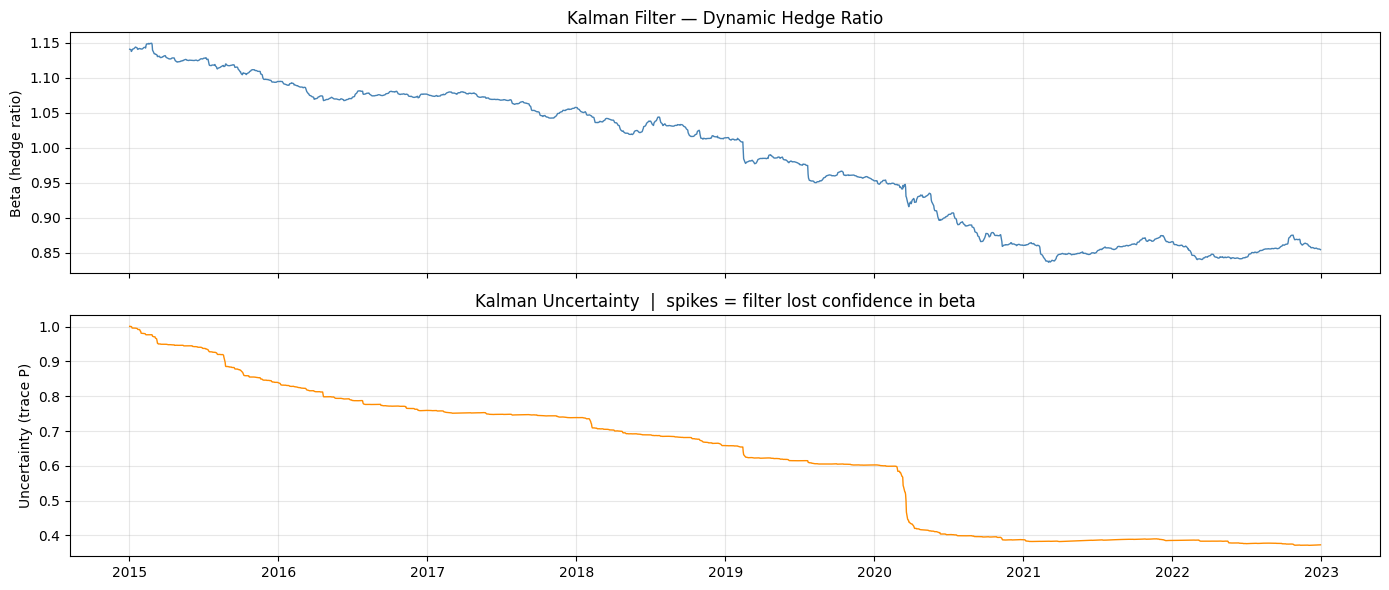

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(kalman_ratios['beta'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Beta (hedge ratio)')
axes[0].set_title('Kalman Filter — Dynamic Hedge Ratio')

axes[1].plot(kalman_ratios['uncertainty'], color='darkorange', linewidth=1)
axes[1].set_ylabel('Uncertainty (trace P)')
axes[1].set_title('Kalman Uncertainty  |  spikes = filter lost confidence in beta')

plt.tight_layout()
plt.show()

## Cell 6 — Plot: Spread

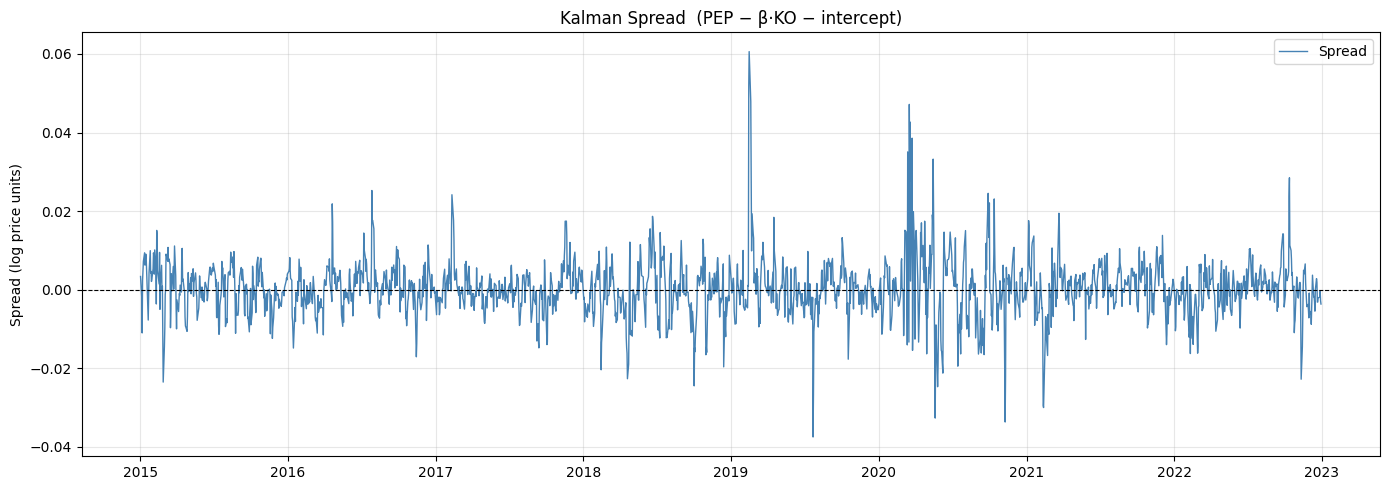

In [43]:
plt.figure()
plt.plot(spread, color='steelblue', linewidth=1, label='Spread')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Kalman Spread  (PEP − β·KO − intercept)')
plt.ylabel('Spread (log price units)')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 7 — Plot: OU half-life over time

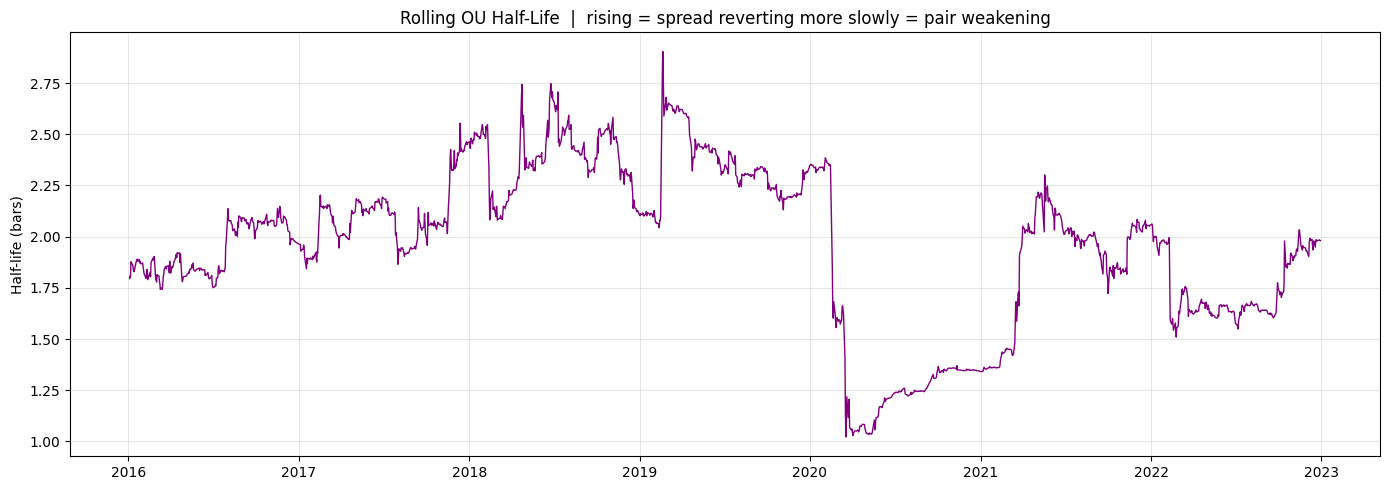

Median half-life : 2.0 bars
Min half-life    : 1.0 bars
Max half-life    : 2.9 bars


In [44]:
plt.figure()
plt.plot(half_life, color='purple', linewidth=1)
plt.title('Rolling OU Half-Life  |  rising = spread reverting more slowly = pair weakening')
plt.ylabel('Half-life (bars)')
plt.tight_layout()
plt.show()

print(f'Median half-life : {half_life.median():.1f} bars')
print(f'Min half-life    : {half_life.min():.1f} bars')
print(f'Max half-life    : {half_life.max():.1f} bars')

## Cell 8 — Plot: Z-score with dynamic thresholds and positions

## Cell 9 — Plot: Cumulative PnL + drawdown

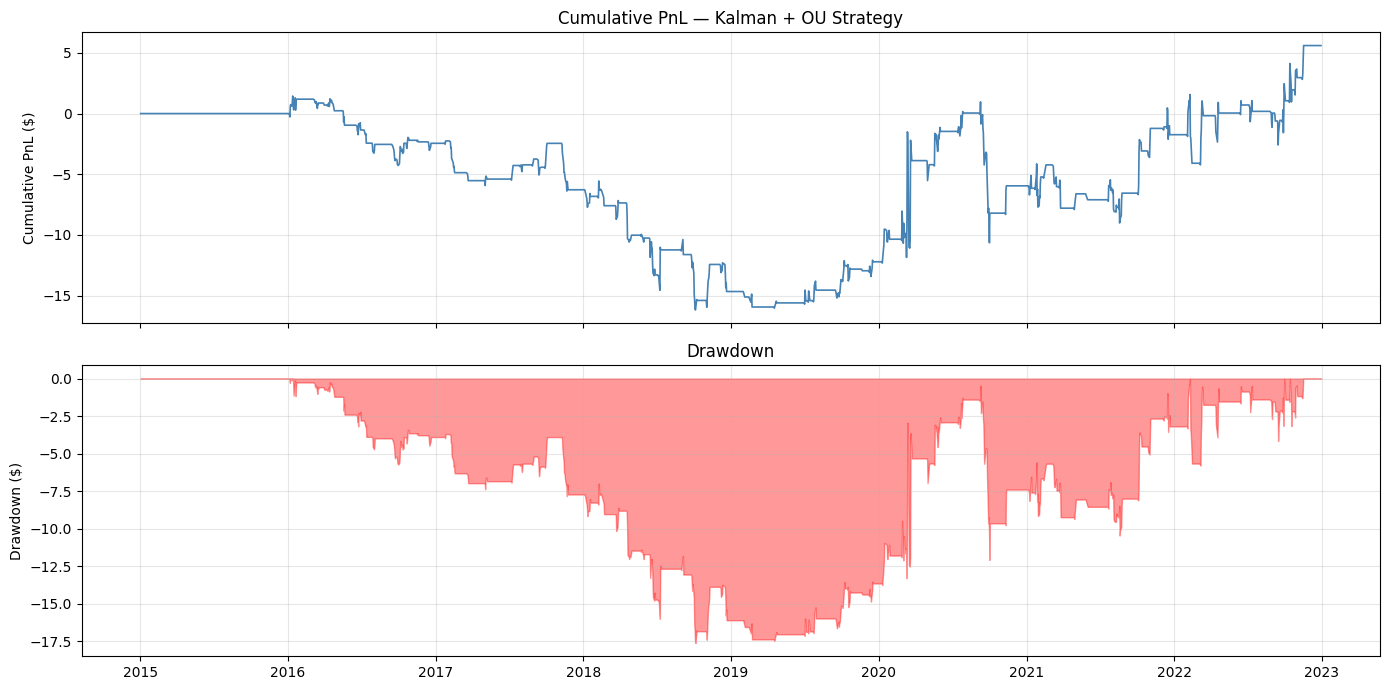

In [46]:
cum_pnl     = bt['cum_pnl']
running_max = cum_pnl.cummax()
drawdown    = cum_pnl - running_max

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(cum_pnl, color='steelblue', linewidth=1.2)
axes[0].set_ylabel('Cumulative PnL ($)')
axes[0].set_title('Cumulative PnL — Kalman + OU Strategy')

axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_title('Drawdown')

plt.tight_layout()
plt.show()

## Cell 10 — Plot: Daily PnL distribution

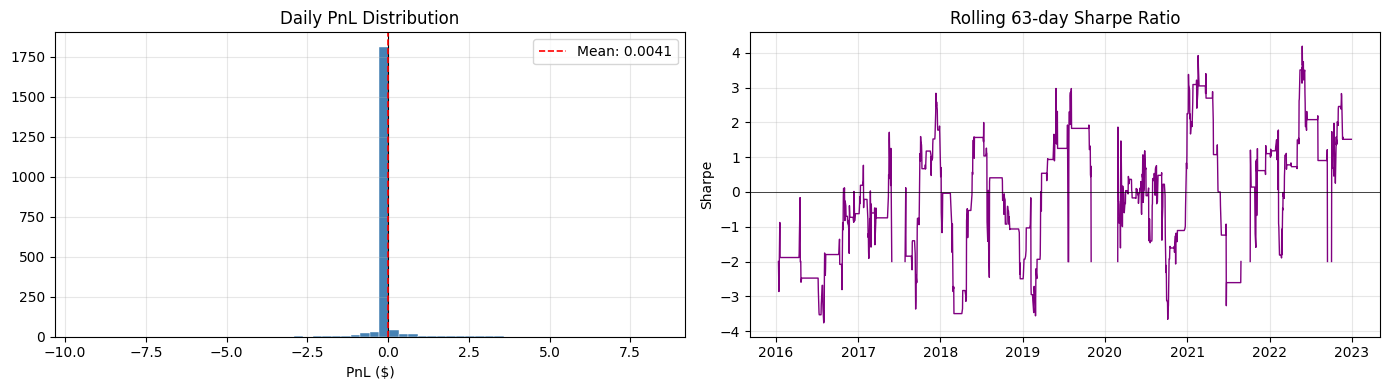

In [ ]:
daily_pnl = bt['daily_pnl'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(daily_pnl, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(daily_pnl.mean(), color='red', linewidth=1.2, linestyle='--', label=f'Mean: {daily_pnl.mean():.4f}')
axes[0].set_title('Daily PnL Distribution')
axes[0].set_xlabel('PnL ($)')
axes[0].legend()

# Rolling Sharpe (63-day)
rolling_sharpe = daily_pnl.rolling(63).apply(
    lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan
)
axes[1].plot(rolling_sharpe, color='purple', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Rolling 63-day Sharpe Ratio')
axes[1].set_ylabel('Sharpe')

plt.tight_layout()
plt.show()

## Cell 11 — Trading cost breakdown

In [ ]:
total_costs  = bt['trading_costs'].sum()
gross_pnl    = (bt['daily_pnl'] + bt['trading_costs']).sum()
net_pnl      = bt['daily_pnl'].sum()
cost_drag_pct = total_costs / abs(gross_pnl) * 100 if gross_pnl != 0 else np.nan

print(f'Gross PnL          : ${gross_pnl:>10.2f}')
print(f'Total trading costs: ${total_costs:>10.2f}')
print(f'Net PnL            : ${net_pnl:>10.2f}')
print(f'Cost drag          : {cost_drag_pct:>9.1f}% of gross')

Gross PnL          : $     32.90
Total trading costs: $     24.71
Net PnL            : $      8.19
Cost drag          :      75.1% of gross


## Cell 12 — Inspect a sample of individual trades

In [ ]:
# Find trade entry and exit bars
pos_diff   = positions.diff().fillna(positions)
entry_bars = positions.index[pos_diff != 0]

trades = []
pos_arr = positions.values
idx     = positions.index

i = 0
while i < len(pos_arr):
    if pos_arr[i] != 0:
        direction = pos_arr[i]
        entry_date = idx[i]
        j = i + 1
        while j < len(pos_arr) and pos_arr[j] == direction:
            j += 1
        exit_date = idx[j - 1]
        trade_pnl = bt['daily_pnl'].iloc[i:j].sum()
        holding   = j - i
        trades.append({
            'entry_date': entry_date,
            'exit_date' : exit_date,
            'direction' : 'Long' if direction == 1 else 'Short',
            'holding_days': holding,
            'pnl'       : round(trade_pnl, 4),
        })
        i = j
    else:
        i += 1

trades_df = pd.DataFrame(trades)
print(f'Total trades: {len(trades_df)}')
print(f'Win rate    : {(trades_df["pnl"] > 0).mean():.1%}')
print(f'Avg holding : {trades_df["holding_days"].mean():.1f} days')
print()
trades_df.head(20)

Total trades: 86
Win rate    : 47.7%
Avg holding : 2.7 days



,entry_date,exit_date,direction,holding_days,pnl
0,2016-01-13,2016-01-19,Long,4,-0.6876
1,2016-04-21,2016-04-22,Short,2,-0.1488
2,2016-07-08,2016-07-11,Short,2,-0.4370
3,2016-07-28,2016-08-01,Short,3,-0.8606
4,2016-08-03,2016-08-09,Long,5,0.1967
5,2016-10-06,2016-10-10,Long,3,-0.2615
6,2016-10-20,2016-10-24,Long,3,0.4547
7,2016-11-15,2016-11-16,Long,2,-0.0695
8,2016-11-21,2016-11-23,Short,3,0.2425
9,2016-12-12,2016-12-12,Long,1,-0.1117
